In [3]:
words = open('D:/Neural Networks/Bigram/names.txt', 'r').read().splitlines()

In [5]:
words[:3], len(words)

(['emma', 'olivia', 'ava'], 32033)

In [12]:
stoi = {chr(ord('a')+i): i+1 for i in range (26)}
stoi['.'] = 0

itos = {v: k for k, v in stoi.items()}

In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [19]:
# preparing the data
block_size = 3

X = []
Y = []

for w in words[:5]:
    context = [0] * block_size  
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)


... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
... ---> a
..a ---> v
.av ---> a
ava ---> .
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [20]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [22]:
# Embedding matrix using 2d for now

C = torch.randn((27, 2))

In [23]:
# embedding 5

C[5]

tensor([0.4723, 0.1546])

In [25]:
# another way to do the same

F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.4723, 0.1546])

In [26]:
# same works with lists or tensors

C[[3, 4, 5]]

tensor([[ 0.6359, -0.8601],
        [-0.3793,  0.8297],
        [ 0.4723,  0.1546]])

In [29]:
C[X].shape # can take tensors as well

torch.Size([32, 3, 2])

In [30]:
C = torch.randn((27, 2))

In [32]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [33]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [36]:
# we need to somehow concatenate [32, 3, 2] into [32, 6] so that we can pass it on into next layer

emb[:, 0, :].shape, emb[:, 1, :].shape, emb[:, 2, :].shape 

(torch.Size([32, 2]), torch.Size([32, 2]), torch.Size([32, 2]))

In [38]:
# we can maybe concat the above three

torch.concat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 6])

In [39]:
# a better way to acheive this

torch.concat(torch.unbind(emb, dim=1), dim = 1).shape

torch.Size([32, 6])

In [40]:
# more better way to do this is using torch view

a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [43]:
a.view((2, 9))

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [44]:
a.view((3, 3, 2))

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [47]:
emb.view((X.shape[0], 6)).shape # best way to do this

torch.Size([32, 6])

In [52]:
h = emb.view((-1, 6)) @ W1 + b1
h.shape

torch.Size([32, 100])

In [53]:
# 2nd MLP layer

W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [54]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [55]:
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True)
prob.shape

torch.Size([32, 27])

In [62]:
prob[1].sum()

tensor(1.)

In [68]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(inf)

In [112]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [113]:
## Combining everything here for more readbility
# embedding
C = torch.randn((27, 2))

# 1st layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

# 2nd MLP layer
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]

In [114]:
sum(p.nelement() for p in parameters)

3481

In [115]:
# Forward pass

emb = C[X] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(15.7060)

In [116]:
F.cross_entropy(logits, Y) # we will use this as this doesnot creates more copies of tensors in the computation graphs and is handled as one atomic operation

tensor(15.7060)

In [184]:
# Train on whole data

def build_dataset(words):
    block_size = 3

    X = []
    Y = []

    for w in words:
        context = [0] * block_size  
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random 
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182645, 3]) torch.Size([182645])
torch.Size([22782, 3]) torch.Size([22782])
torch.Size([22719, 3]) torch.Size([22719])


In [194]:
## Combining everything here for more readbility
# embedding
C = torch.randn((27, 2))

# 1st layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

# 2nd MLP layer
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]

In [195]:
for p in parameters:
    p.requires_grad = True

In [196]:
losses = []
steps = []

In [151]:
# training loop (Batch gradient descent)

for i in range(50):
    # Forward pass
    emb = C[X] # (X[0], 32, 2)
    h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits, Y)
    
    losses.append(loss.item())
    steps.append(0 if len(steps) == 0 else steps[-1]+1)

    # backprop
    for p in parameters:
        p.grad = None 
    loss.backward()

    # grad descent
    for p in parameters:
        p.data -= 0.1 * p.grad

print(loss.item())

4.383045673370361


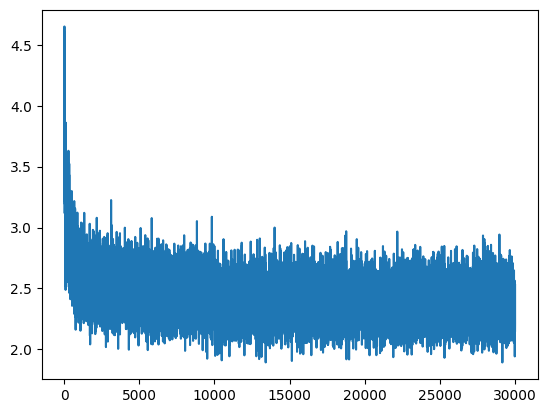

In [182]:
plt.plot(steps, losses)

In [197]:
losses = []
steps = []

In [205]:
# training loop (Mini Batch gradient descent)

for i in range(30000):
    # we will get a minibatch
    ix = torch.randint(0, Xtr.shape[0], (64,))
    # Forward pass
    emb = C[Xtr[ix]] # (X[0], 32, 2)
    h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    losses.append(loss.item())  
    steps.append(0 if len(steps) == 0 else steps[-1]+1)

    # backprop
    for p in parameters:
        p.grad = None 
        
    loss.backward()

    # grad descent
    for p in parameters:
        p.data -= 0.01 * p.grad

print(loss.item())


2.2411141395568848


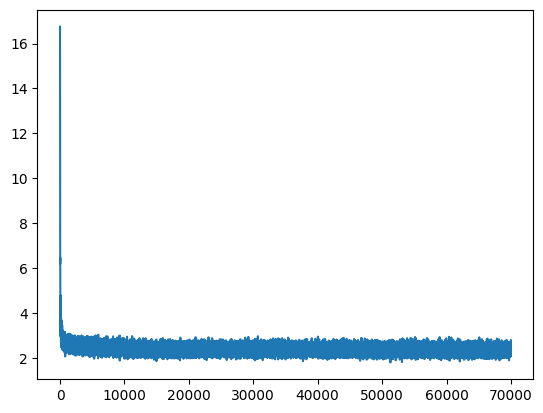

In [206]:
plt.plot(steps, losses)

In [ ]:
# loss on full set

emb = C[X] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3709, grad_fn=<NllLossBackward0>)

In [208]:
# loss on Validation set

emb = C[Xdev] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3826, grad_fn=<NllLossBackward0>)

In [209]:
# loss on test set

emb = C[Xtest] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 6)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ytest)
loss

tensor(2.3683, grad_fn=<NllLossBackward0>)

***Inference***

In [210]:
for _ in range(20):
    prev = torch.zeros((1, 3), dtype=torch.long)
    chars = []
    while True:
        emb = C[prev]
        h = torch.tanh(emb.view((-1, 6)) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)

        next_ix = torch.multinomial(prob, num_samples=1).item()

        if next_ix == 0:
            break

        chars.append(itos[next_ix])

        prev = torch.cat([
            prev[:, 1:],
            torch.tensor([[next_ix]])
        ], dim=1)

    print(''.join(chars))

karylyen
nalaenaghiu
jaxa
nai
ken
kariyko
sfenra
areyeh
daractonalwor
jarto
kya
warke
hoca
danibhyn
jessivussanoa
aliaphin
reph
kaza
zossahpesn
masia


***Embedding Visualization***

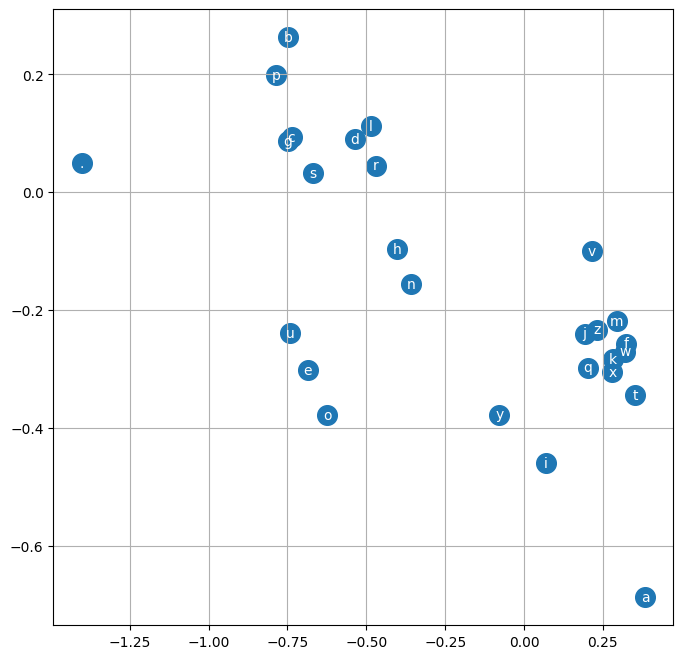

In [219]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s = 200)

for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")


***Train with a higher dimension embeddings***

In [235]:
## Combining everything here for more readbility
# embedding
C = torch.randn((27, 10))

# 1st layer
W1 = torch.randn((30, 200))
b1 = torch.randn(200)

# 2nd MLP layer
W2 = torch.randn((200, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

In [236]:
losses = []
steps = []

In [247]:
# training loop (Mini Batch gradient descent)

for i in range(30000):
    # we will get a minibatch
    ix = torch.randint(0, Xtr.shape[0], (128,))
    # Forward pass
    emb = C[Xtr[ix]] # (X[0], 32, 2)
    h = torch.tanh(emb.view((-1, 30)) @ W1 + b1) # (x[0], 100)
    logits = h @ W2 +b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    losses.append(loss.log10().item())  
    steps.append(0 if len(steps) == 0 else steps[-1]+1)

    # backprop
    for p in parameters:
        p.grad = None 
        
    loss.backward()

    # grad descent
    for p in parameters:
        p.data -= 0.01 * p.grad

print(loss.item())


2.0208892822265625


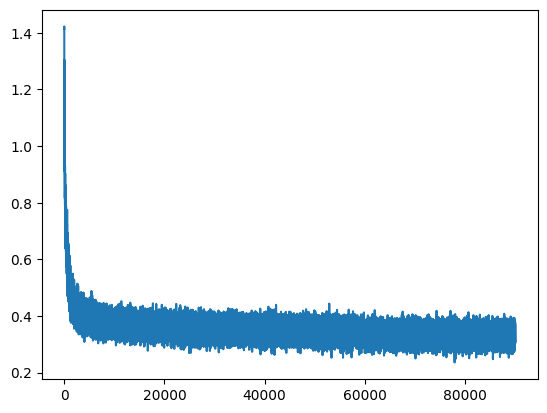

In [248]:
plt.plot(steps, losses)

In [249]:
# loss on Validation set

emb = C[Xdev] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 30)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1924, grad_fn=<NllLossBackward0>)

In [250]:
# loss on test set

emb = C[Xtest] # (X[0], 32, 2)
h = torch.tanh(emb.view((-1, 30)) @ W1 + b1) # (x[0], 100)
logits = h @ W2 +b2
loss = F.cross_entropy(logits, Ytest)
loss

tensor(2.1766, grad_fn=<NllLossBackward0>)

In [253]:
for _ in range(20):
    prev = torch.zeros((1, 3), dtype=torch.long)
    chars = []
    while True:
        emb = C[prev]
        h = torch.tanh(emb.view((-1, 30)) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)

        next_ix = torch.multinomial(prob, num_samples=1).item()

        if next_ix == 0:
            break

        chars.append(itos[next_ix])

        prev = torch.cat([
            prev[:, 1:],
            torch.tensor([[next_ix]])
        ], dim=1)

    print(''.join(chars))

ani
sita
end
har
zyria
amon
bael
aleigh
emmania
tavo
sadheethamny
ladokrinnliam
kaydeneithane
ius
matre
melamarit
acyliah
dan
harian
katpan


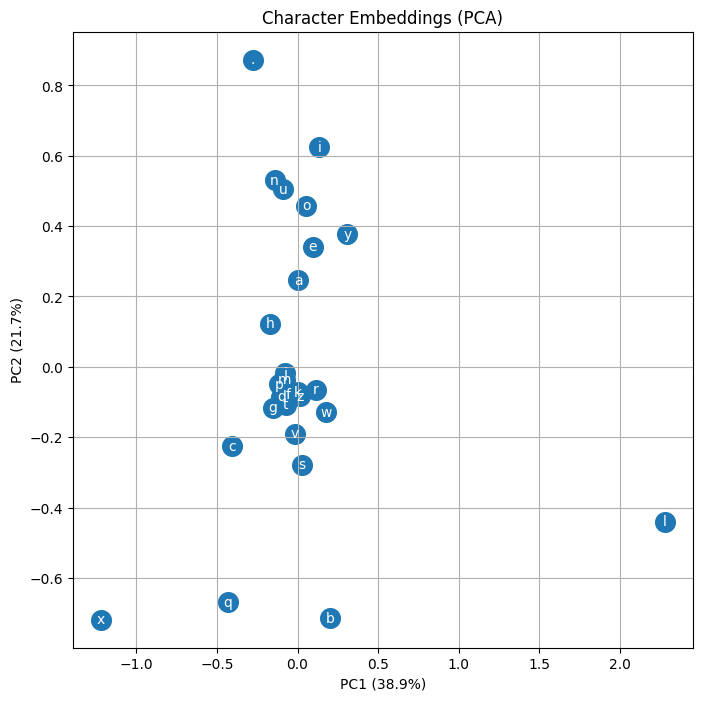

Total variance explained: 0.6056247


In [252]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# C shape = (27, 10)
X = C.detach().cpu().numpy()

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8, 8))
plt.scatter(X2[:, 0], X2[:, 1], s=200)

for i in range(C.shape[0]):
    plt.text(
        X2[i, 0],
        X2[i, 1],
        itos[i],
        ha="center",
        va="center",
        color="white"
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
plt.title("Character Embeddings (PCA)")
plt.grid()
plt.show()

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)